         Date    Product  Sales  Quantity Region
0  2023-01-01  Product A    200         4  North
1  2023-01-02  Product B    150         3  South
2  2023-01-03  Product A    220         5  North
3  2023-01-04  Product C    300         6   East
4  2023-01-05  Product B    180         4   West

Date        0
Product     0
Sales       0
Quantity    0
Region      0
dtype: int64

            Sales   Quantity
count   16.000000  16.000000
mean   237.500000   5.375000
std     64.031242   1.746425
min    150.000000   3.000000
25%    187.500000   4.000000
50%    225.000000   5.500000
75%    302.500000   7.000000
max    340.000000   8.000000

     Product  Sales  Quantity
0  Product A   1350        33
1  Product B    850        17
2  Product C   1600        36



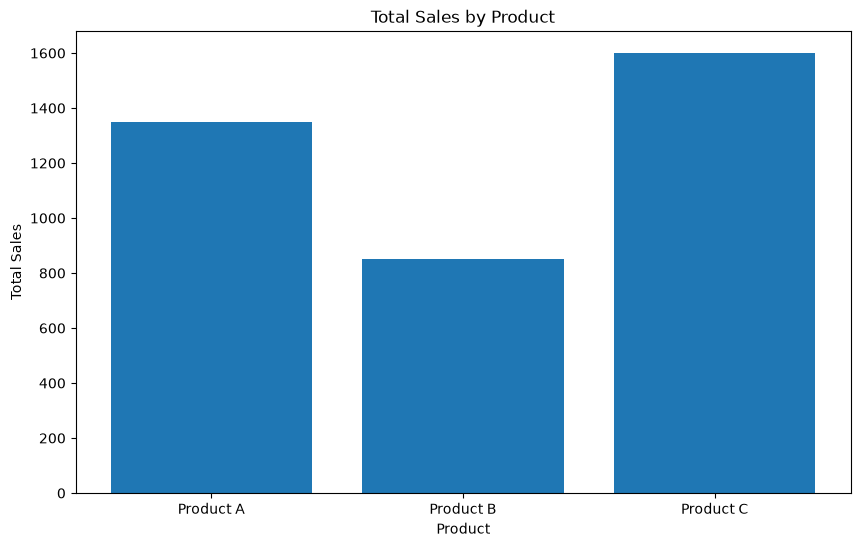

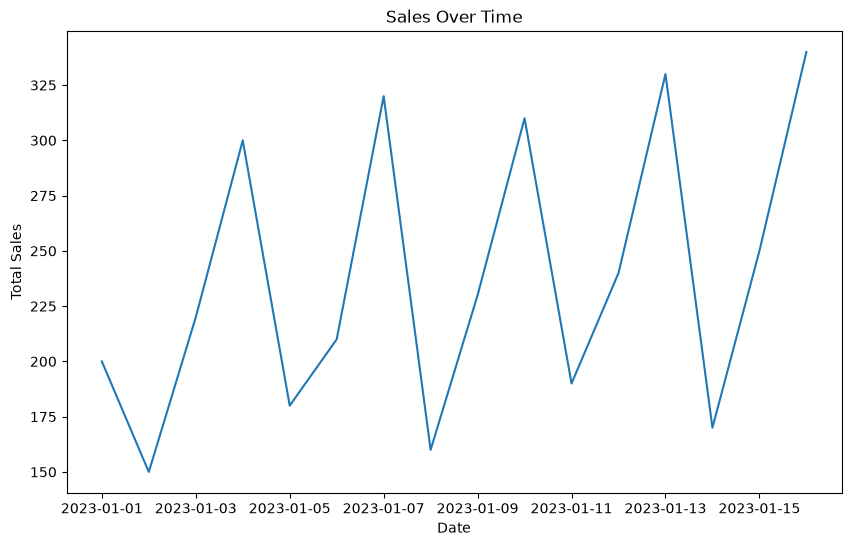


Product  Product A  Product B  Product C
Region                                  
East             0          0       1600
North         1350          0          0
South            0        480          0
West             0        370          0

             Sales  Quantity
Sales     1.000000  0.408373
Quantity  0.408373  1.000000



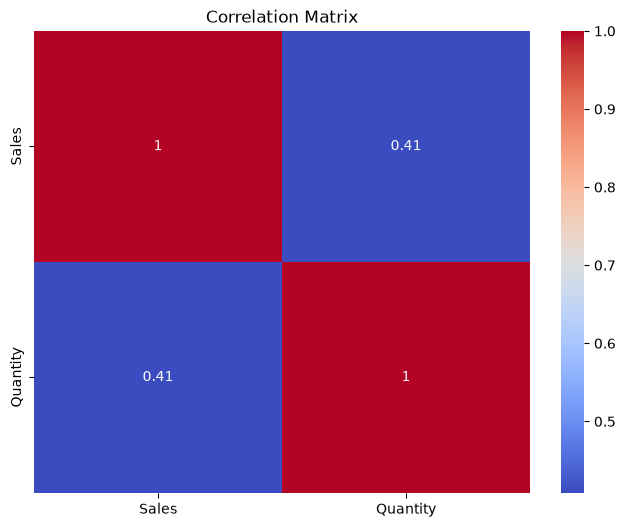

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
# Load the data into a pandas DataFrame 
file_path= r'D:\FDS_LAB\sales_data.csv' 
df = pd.read_csv(file_path) 

# Display the first few rows of the DataFrame 
print(df.head()) 
print()

# Check for missing values 
print(df.isnull().sum()) 
print()

# Fill or drop missing values if necessary 
df['Sales'] = df['Sales'].fillna(df['Sales'].mean())
df.dropna(subset=['Product', 'Quantity', 'Region'], inplace=True) 

# Summary statistics 
print(df.describe()) 
print()

# Group by product and calculate the total sales and quantity 
product_summary = df.groupby('Product').agg({ 
    'Sales': 'sum', 
    'Quantity': 'sum' 
}).reset_index() 
print(product_summary)  
print()

# Bar plot of total sales by product 
plt.figure(figsize=(10, 6)) 
plt.bar(product_summary['Product'], product_summary['Sales']) 
plt.xlabel('Product') 
plt.ylabel('Total Sales') 
plt.title('Total Sales by Product') 
plt.show() 
print()

# Line plot of sales over time 
df['Date'] = pd.to_datetime(df['Date']) 
sales_over_time = df.groupby('Date').agg({'Sales': 'sum'}).reset_index() 
plt.figure(figsize=(10, 6)) 
plt.plot(sales_over_time['Date'], sales_over_time['Sales']) 
plt.xlabel('Date') 
plt.ylabel('Total Sales') 
plt.title('Sales Over Time') 
plt.show() 
print()

# Pivot table to analyze sales by region and product 
pivot_table = df.pivot_table(values='Sales', index='Region', columns='Product', 
aggfunc=np.sum, fill_value=0) 
print(pivot_table)
print()

# Correlation matrix
correlation_matrix = df.corr(numeric_only=True)
print(correlation_matrix)
print()

# Heatmap of the correlation matrix 
import seaborn as sns 
plt.figure(figsize=(8, 6)) 
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm') 
plt.title('Correlation Matrix') 
plt.show()